### Implementation of QLoRA with BERT on AG News Classification

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, BitsAndBytesConfig
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import evaluate
import torch

dataset = load_dataset("ag_news")

train_dataset = dataset["train"].shuffle(seed=42)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

from datasets import DatasetDict
dataset = DatasetDict({
    "train": train_dataset.select(range(train_size)),
    "validation": train_dataset.select(range(train_size, train_size + val_size)),
    "test": dataset["test"]
})



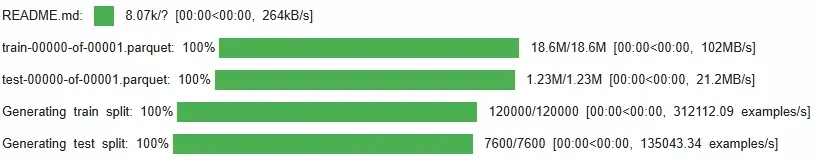

In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(preprocess, batched=True).rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

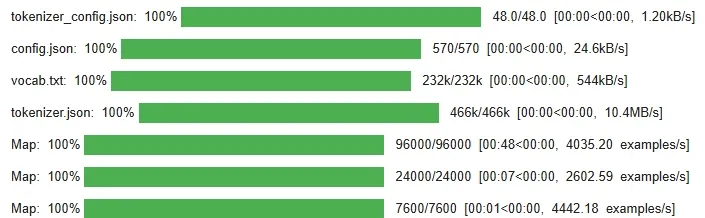

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,  
    device_map="auto",
    quantization_config=bnb_config
)



In [ ]:
qlora_adapter_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

model = get_peft_model(model, qlora_adapter_config)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return metric.compute(predictions=preds, references=labels)

qlora_training_args = TrainingArguments(
    output_dir="./qlora_agnews",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    num_train_epochs=2,
    eval_strategy="epoch",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    qlora_training_args=qlora_training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()
model.save_pretrained("./qlora_agnews_adapter")
print("QLoRA fine-tuning complete! Adapter saved at ./qlora_agnews_adapter")



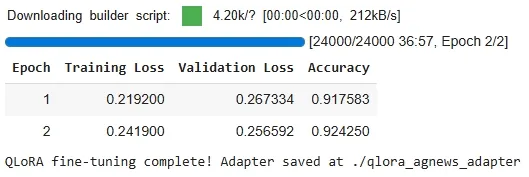

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

class_labels = dataset["train"].features["labels"].names

samples = [
    "The stock market closed at an all-time high today.",
    "The football team won the championship after a thrilling game.",
    "Scientists discovered a new exoplanet in the habitable zone.",
    "The president met with foreign leaders to discuss trade agreements."
]

inputs = tokenizer(samples, truncation=True, padding=True, return_tensors="pt").to(device)

model.eval()
with torch.no_grad():
    logits = model(**inputs).logits
    preds = torch.argmax(logits, dim=-1)

for text, pred in zip(samples, preds):
    print(f"News: {text}\nPredicted Topic: {class_labels[pred]}\n")

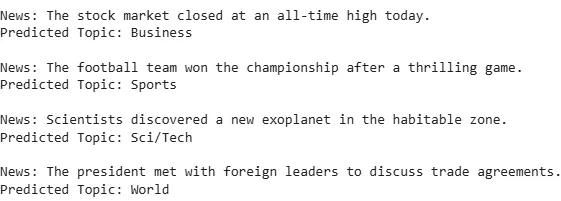